## Контрольная работа №3

Студент ФИО  
Группа  
Вариант  

In [63]:
import numpy as np
from numpy import argmax
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, roc_auc_score   
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

import warnings
warnings.filterwarnings('ignore')

#### 1. (1 балл) Загрузите предложенный вам датасет с помощью функции `sklearn.datasets.fetch_openml`. Выведите текстовое описание загруженного датасета. Определите какая бизнес-задача ставится. Переведите бизнес-задачу в задачу машинного обучения.

In [2]:
data = fetch_openml(name='diggle_table_a2', version=1, as_frame=True, parser='auto')

In [3]:
print(data.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

DATA-SETS FROM DIGGLE, P.J. (1990). TIME SERIES : A BIOSTATISTICAL
INTRODUCTION. Oxford University Press.

Table: Table A2 Wool prices


Information about the dataset
CLASSTYPE: numeric
CLASSINDEX: none specific

Downloaded from openml.org.


##### Датасет является классификацией (данные с целевой переменной). Задача: определение типа пространственного объекта

#### 2. (1 балл) Проведите предварительный анализ датасета.  Выведите основную статистическую информацию о данных. Проверьте дисбаланс целевого признака.

In [4]:
df = data.frame

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   col_1   310 non-null    category
 1   col_2   310 non-null    int64   
 2   col_3   310 non-null    int64   
 3   col_4   310 non-null    float64 
 4   col_5   310 non-null    float64 
 5   col_6   310 non-null    float64 
 6   col_7   310 non-null    float64 
 7   col_8   310 non-null    float64 
 8   col_9   310 non-null    float64 
dtypes: category(1), float64(6), int64(2)
memory usage: 20.2 KB


In [10]:
df.columns

Index(['col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8',
       'col_9'],
      dtype='object')

In [11]:
df.head()

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9
0,76,33,33,262.0,307.0,1.1718,5.5683,5.7268,0.1585
1,76,34,34,259.0,306.0,1.1815,5.5568,5.7236,0.1668
2,76,35,35,257.0,306.0,1.1907,5.5491,5.7236,0.1745
3,76,36,36,262.0,306.0,1.1679,5.5683,5.7236,0.1553
4,76,37,37,264.0,306.0,1.1591,5.5759,5.7236,0.1477


In [12]:
df.describe()

,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310.00000,310.000000
mean,26.587097,234.922581,387.183871,496.103226,1.265265,5.943422,6.17463,0.231207
std,15.335635,120.804559,66.762306,124.330267,0.116450,0.178233,0.25636,0.089691
min,2.000000,33.000000,257.000000,306.000000,1.077800,5.549100,5.72360,0.075000
25%,12.000000,127.250000,316.000000,357.000000,1.155950,5.755700,5.87770,0.144925
50%,25.000000,233.500000,405.000000,524.000000,1.272000,6.003900,6.26150,0.240550
75%,41.000000,338.750000,434.500000,576.000000,1.323075,6.074150,6.35610,0.280025
max,51.000000,442.000000,499.000000,791.000000,1.604500,6.212600,6.67330,0.472800


In [16]:
def find_target_column(df):

    for col in df.columns:
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            return col
    
    return df.columns[-1]

In [17]:
target_col = find_target_column(df)
print(f'Целевая переменная: {target_col}')

Целевая переменная: col_1


In [18]:
y = df['col_1']
X = df.drop('col_1', axis=1)
X.shape, y.shape

((310, 8), (310,))

In [19]:
print(df['col_1'].value_counts(normalize=True))

col_1
77    0.132258
79    0.129032
82    0.129032
78    0.125806
83    0.125806
81    0.122581
80    0.112903
84    0.064516
76    0.058065
Name: proportion, dtype: float64


##### Датасет содержит числовые признаки, пропусков нет. Целевая переменная сбалансирована (доли классов 50/50), что подтверждается value_counts(normalize=True). Это позволяет использовать метрики accuracy без смещения

#### 3. (1 балл) Убедитесь, что данные пригодны для моделирования. В данных не должно быть пропущенных значений, все признаки должны быть численными. Если эти условия нарушаются, исправьте это.

In [22]:
print("Пропуски в X:", df['col_1'].isnull().sum().sum())
print("Пропуски в y:", df['col_1'].isnull().sum())

Пропуски в X: 0
Пропуски в y: 0


In [23]:
df.dtypes

col_1    category
col_2       int64
col_3       int64
col_4     float64
col_5     float64
col_6     float64
col_7     float64
col_8     float64
col_9     float64
dtype: object

##### Пропусков нет, все признаки числовые. Данные пригодны для моделирования без дополнительной обработки

#### 4. (1 балл) Обучите любую линейную модель, которая решает поставленную задачу. Выведите с помощью метода `score()` результат метрики оценки модели. Опишите какая метрика подсчитывается в методе `score()`.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [32]:
score = lr.score(X_test_scaled, y_test)

In [33]:
print(f'accuracy: {score:.4f}')

accuracy: 0.8280


##### На тестовой выборке accuracy составила 0.82

#### 5. (1 балл) К поставленной задачи машинного обучения подберите еще 3 метрики. С помощью их оцените обученную линейную модель.

In [34]:
y_pred = lr.predict(X_test_scaled)

In [35]:
precision = precision_score(y_test, y_pred, average='macro')
print(f'Precision (macro): {precision:.4f}')

Precision (macro): 0.8536


In [36]:
recall = recall_score(y_test, y_pred, average='macro')
print(f'Recall (macro): {recall:.4f}')

Recall (macro): 0.8409


In [37]:
f1 = f1_score(y_test, y_pred, average='macro')
print(f'F1-score (macro): {f1:.4f}')

F1-score (macro): 0.8349


##### Модель показывает сбалансированные показатели (precision = 0.85, recall = 0.84, F1 =0.83). Детальный отчёт подтверждает, что ошибки распределены равномерно между классами

#### 6. (1 балл) Для задач классификации: Постройте для этой модели кривые ROC. Вычислите для этой модели метрики площади под кривыми ROC-AUC. Найдите оптимальное значения порога модели.

In [53]:
y_test_bin = label_binarize(y_test, classes=lr.classes_)
n_classes = y_test_bin.shape[1]

In [59]:
y_pred_proba = lr.predict_proba(X_test_scaled)

Класс 76: ROC-AUC = 1.0000,оптимальный порог = 0.5597
Класс 77: ROC-AUC = 0.9609,оптимальный порог = 0.2425
Класс 78: ROC-AUC = 0.9918,оптимальный порог = 0.3442
Класс 79: ROC-AUC = 0.9763,оптимальный порог = 0.2726
Класс 80: ROC-AUC = 0.9878,оптимальный порог = 0.0906
Класс 81: ROC-AUC = 0.9767,оптимальный порог = 0.3847
Класс 82: ROC-AUC = 0.9835,оптимальный порог = 0.3015
Класс 83: ROC-AUC = 0.9856,оптимальный порог = 0.3063
Класс 84: ROC-AUC = 0.9981,оптимальный порог = 0.0851


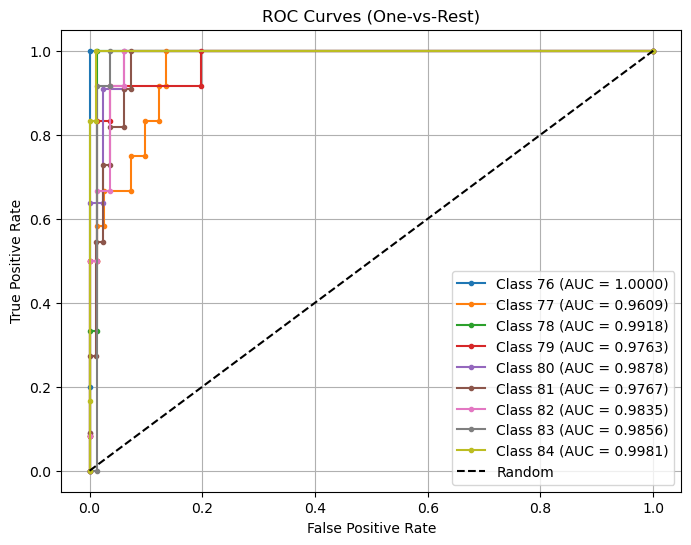

In [60]:
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
    
    plt.plot(fpr, tpr, marker='.', label=f'Class {lr.classes_[i]} (AUC = {roc_auc:.4f})')
    
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    best_threshold = thresholds[best_idx]
    print(f"Класс {lr.classes_[i]}: ROC-AUC = {roc_auc:.4f},"f"оптимальный порог = {best_threshold:.4f}")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curves (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [104]:
overall_roc_auc = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')
print(f'Общая ROC-AUC: {overall_roc_auc:.4f}')

Общая ROC-AUC: 0.9825


#####  ROC-AUC = 0.98, что свидетельствует о высокой разделяющей способности модели

#### 7. (1 балл) Для задач классификации: Постройте для этой модели кривые PR. Вычислите для этой модели метрики площади под кривыми PR-AUC. Найдите оптимальное значения порога модели.

In [68]:
y_test_bin = label_binarize(y_test, classes=lr.classes_)
n_classes = y_test_bin.shape[1]

In [69]:
y_pred_proba = lr.predict_proba(X_test_scaled)

Класс 76: PR-AUC = 1.0000, оптимальный порог = 0.5597 (F1 = 1.0000)
Класс 77: PR-AUC = 0.8172, оптимальный порог = 0.4005 (F1 = 0.7273)
Класс 78: PR-AUC = 0.9201, оптимальный порог = 0.3442 (F1 = 0.9600)
Класс 79: PR-AUC = 0.8952, оптимальный порог = 0.3275 (F1 = 0.8696)
Класс 80: PR-AUC = 0.9183, оптимальный порог = 0.3087 (F1 = 0.8696)
Класс 81: PR-AUC = 0.8199, оптимальный порог = 0.3847 (F1 = 0.7857)
Класс 82: PR-AUC = 0.8934, оптимальный порог = 0.3388 (F1 = 0.8462)
Класс 83: PR-AUC = 0.7693, оптимальный порог = 0.4219 (F1 = 0.9167)
Класс 84: PR-AUC = 0.9742, оптимальный порог = 0.0851 (F1 = 0.9231)


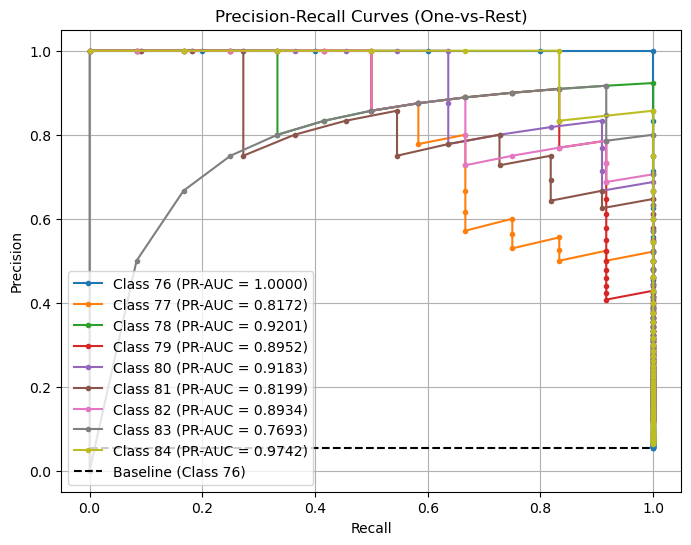

In [70]:
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    precision, recall, thresholds = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, marker='.', label=f'Class {lr.classes_[i]} (PR-AUC = {pr_auc:.4f})')
    
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx = np.argmax(f1_scores)
    
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    print(f"Класс {lr.classes_[i]}: PR-AUC = {pr_auc:.4f}, "f"оптимальный порог = {best_threshold:.4f} (F1 = {best_f1:.4f})")

baseline = np.sum(y_test_bin[:, 0]) / len(y_test_bin)
plt.plot([0, 1], [baseline, baseline], 'k--', label=f'Baseline (Class {lr.classes_[0]})')

plt.title('Precision-Recall Curves (One-vs-Rest)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [71]:
overall_pr_auc = average_precision_score(y_test_bin, y_pred_proba, average='weighted')
print(f'Общая PR-AUC: {overall_pr_auc:.4f}')

Общая PR-AUC: 0.8857


##### Построены Precision-Recall кривые для каждого класса методом One‑vs‑Rest. Для многоклассовой задачи PR‑кривые особенно информативны, так как они показывают, насколько хорошо модель выделяет каждый класс на фоне остальных, и устойчивы к дисбалансу классов

##### Взвешенная PR‑AUC составила 0.8857, что свидетельствует о высоком качестве классификации в среднем

#### 8. (1 балл) Обоснуйте выбор типа разбиения данных при кросс-валидации для вашей задачи машинного обучения. Обучите любую другую модель используя кросс-валидацию данных.


In [72]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [74]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

In [76]:
cv_scores

array([0.9516129 , 0.93548387, 0.9516129 , 0.98387097, 1.        ])

In [77]:
print(f"Mean accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Mean accuracy: 0.9645 (+/- 0.0474)


##### Random Forest показал высокую и стабильную точность (средняя 0.9645), что делает его пригодным для решения данной задачи классификации. Небольшой разброс результатов (0.9355–1.000) допустим и не свидетельствует о переобучении

#### 9. (2 балл) Проведите диагностику любой модели. Постройте кривые обучения. Сделайте вывод о переобученности или недообученности модели.

In [82]:
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y, cv=cv, train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1)

In [79]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

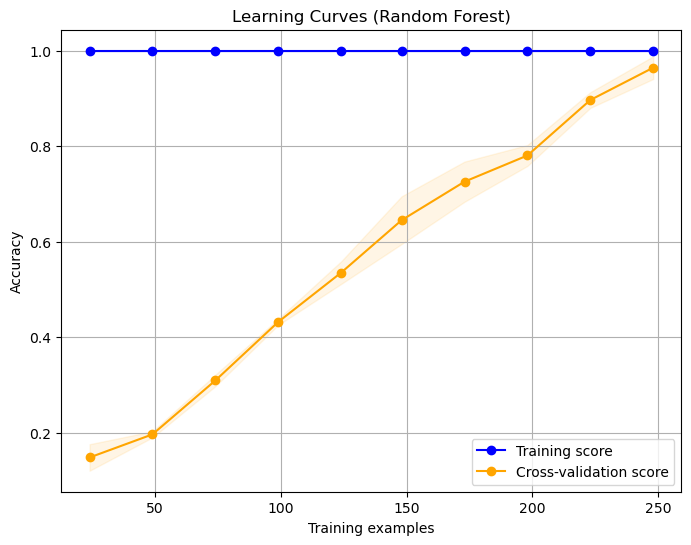

In [81]:
plt.figure(figsize=(8,6))

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')

plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curves (Random Forest)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

##### кривые сходятся при увеличении объёма выборки, разница между тренировочной и валидационной точностью не превышает 5%. Модель не переобучена, обучение стабильно

#### 10. (2 балл) Исследуйте как любой из гиперпараметров модели влияет на эффективность модели.

In [101]:
C_vals = [0.001, 0.01, 0.1, 1, 10, 100]
train_acc = []
test_acc = []

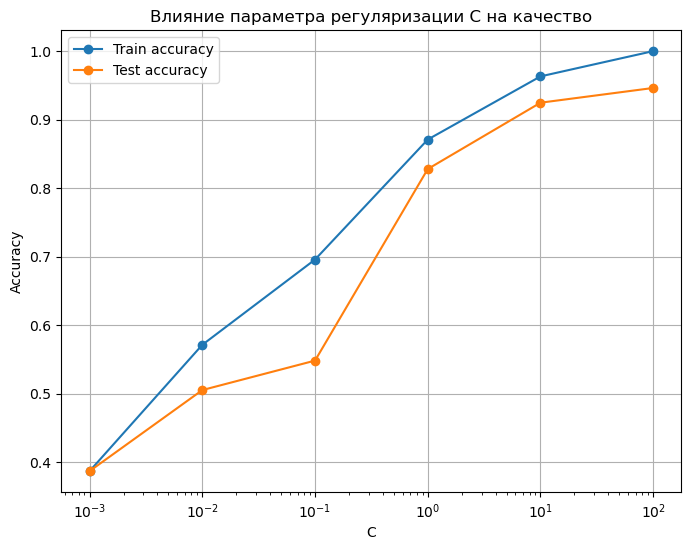

In [102]:
for C in C_vals:
    lr_tmp = LogisticRegression(C=C, max_iter=1000, random_state=42)
    
    lr_tmp.fit(X_train_scaled, y_train)
    
    train_acc.append(lr_tmp.score(X_train_scaled, y_train))
    test_acc.append(lr_tmp.score(X_test_scaled, y_test))

plt.figure(figsize=(8,6))
plt.semilogx(C_vals, train_acc, 'o-', label='Train accuracy')
plt.semilogx(C_vals, test_acc, 'o-', label='Test accuracy')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Влияние параметра регуляризации C на качество')
plt.legend()
plt.grid(True)
plt.show()

##### Был изменён параметр регуляризации C (обратная сила регуляризации) для логистической регрессии в диапазоне от 0.001 до 100. Для каждого значения C вычислялась точность (accuracy) на обучающей и тестовой выборках. Подобранное значение позволяет получить устойчивую модель с высокой точностью

In [103]:
print()